<a href="https://colab.research.google.com/github/smshozab/AG-AquaSense/blob/main/AAIn2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


This notebook implements the **Visual Pathway** of AquaSense-Agent as described in the IEEE paper.  
It covers:
1. Dataset loading & preprocessing (7 fish disease categories)
2. YOLOv11n ROI detection on fish images
3. Fine-tuning MobileNetV2, DenseNet121, VGG16
4. Stacking meta-learner ensemble → outputs `P_cnn`
5. Evaluation: per-class Precision, Recall, F1 + Macro-F1

**Disease Categories (from dataset):**
- Bacterial Red Disease
- Aeromoniasis
- Bacterial Gill Disease
- Saprolegniasis
- Healthy Fish
- Parasitic Diseases
- White Tail Disease

## 📦 Section 0: Install Dependencies

In [2]:
# Run this cell once to install all required packages
!pip install ultralytics torch torchvision scikit-learn matplotlib seaborn Pillow tqdm numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 65.2 MB/s eta 0:00:00


## 📂 Section 1: Imports & Configuration

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import PIL.Image  # Changed from 'from PIL import Image'
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import train_test_split

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device    : {DEVICE}")

PyTorch version : 2.11.0+cu128
CUDA available  : True
Using device    : cuda


In [17]:
# ─── CONFIGURATION ────────────────────────────────────────────────────────────

# Path to your dataset root (ImageFolder structure expected)
# dataset/
#   train/
#     Bacterial_Red_Disease/  image1.jpg ...
#     Aeromoniasis/           image1.jpg ...
#     ...etc
#   val/
#     ...
#   test/
#     ...

DATASET_DIR  = '/content/dataset.zip'        # <-- change to your path
YOLO_WEIGHTS = 'yolo11n.pt'       # downloaded automatically by ultralytics
ROI_CONF_THRESHOLD = 0.7          # from paper: θ=0.7
IMG_SIZE     = 224
BATCH_SIZE   = 32
NUM_EPOCHS   = 15
LEARNING_RATE = 1e-4
NUM_CLASSES  = 7

DISEASE_CLASSES = [
    'Bacterial Red disease',
    'Bacterial diseases - Aeromoniasis',
    'Bacterial gill disease',
    'Fungal diseases Saprolegniasis',
    'Healthy_Fish',
    'Parasitic diseases',
    'Viral diseases White tail disease'
]

print("Configuration loaded.")
print(f"Disease classes : {DISEASE_CLASSES}")

Configuration loaded.
Disease classes : ['Bacterial Red disease', 'Bacterial diseases - Aeromoniasis', 'Bacterial gill disease', 'Fungal diseases Saprolegniasis', 'Healthy_Fish', 'Parasitic diseases', 'Viral diseases White tail disease']


In [18]:
import zipfile

# Unzip the dataset if it's a zip file
if DATASET_DIR.endswith('.zip'):
    print(f"Unzipping {DATASET_DIR}...")
    with zipfile.ZipFile(DATASET_DIR, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    DATASET_DIR = '/content/dataset' # Update DATASET_DIR to the unzipped folder
    print(f"Dataset unzipped to {DATASET_DIR}")

if not os.path.exists(os.path.join(DATASET_DIR, 'train')):
    print("[ERROR] Expected 'train' directory not found inside DATASET_DIR.")
    print("        Please ensure your dataset zip extracts to a 'dataset' folder with 'train', 'val', 'test' subfolders.")


Unzipping /content/dataset.zip...
Dataset unzipped to /content/dataset


In [19]:
print("Listing contents of DATASET_DIR:")
!ls -F {DATASET_DIR}

# Adjust DATASET_DIR if the 'train' folder is nested inside another folder, e.g., 'dataset'
# For example, if 'ls -F /content/dataset' shows 'dataset/', then uncomment and run the line below:
# DATASET_DIR = os.path.join(DATASET_DIR, 'dataset')

# Re-check after potential adjustment
if not os.path.exists(os.path.join(DATASET_DIR, 'train')):
    print(f"\n[WARNING] 'train' directory still not found at {os.path.join(DATASET_DIR, 'train')}.")
    print("          Please manually inspect the output of 'ls -F /content/dataset/' and adjust DATASET_DIR if necessary.")
else:
    print(f"\n'train' directory found at {os.path.join(DATASET_DIR, 'train')}. DATASET_DIR is set correctly.")

Listing contents of DATASET_DIR:
test/  Test/  train/  Train/  Train.csv  val/

'train' directory found at /content/dataset/train. DATASET_DIR is set correctly.


In [35]:
import os
import shutil
import numpy as np

# Consolidate capitalized Train/Test directories into lowercase train/test
def consolidate_dirs(root_dir, upper_case_name, lower_case_name):
    upper_path = os.path.join(root_dir, upper_case_name)
    lower_path = os.path.join(root_dir, lower_case_name)

    if os.path.exists(upper_path):
        print(f"Consolidating '{upper_case_name}/' into '{lower_case_name}/'...")
        # If lowercase doesn't exist, simply rename
        if not os.path.exists(lower_path):
            os.rename(upper_path, lower_path)
            print(f"  Renamed '{upper_case_name}/' to '{lower_case_name}/'.")
        else: # Both exist, move contents
            print(f"  Both '{upper_case_name}/' and '{lower_case_name}/' exist. Moving contents...")
            # Ensure the destination directory has the class subfolders
            for class_name_in_upper_dir in os.listdir(upper_path):
                src_class_path = os.path.join(upper_path, class_name_in_upper_dir)
                dst_class_path = os.path.join(lower_path, class_name_in_upper_dir)

                if os.path.isdir(src_class_path):
                    os.makedirs(dst_class_path, exist_ok=True)
                    for item in os.listdir(src_class_path):
                        src_file = os.path.join(src_class_path, item)
                        dst_file = os.path.join(dst_class_path, item)
                        if os.path.exists(dst_file):
                            print(f"    Warning: Skipping '{item}' as it already exists in '{dst_class_path}'")
                        else:
                            shutil.move(src_file, dst_file)
            shutil.rmtree(upper_path) # Remove the now empty capitalized folder
            print(f"  Contents moved and '{upper_case_name}/' removed.")

consolidate_dirs(DATASET_DIR, 'Train', 'train')
consolidate_dirs(DATASET_DIR, 'Test', 'test')


# Create a validation set by splitting the training data
TRAIN_PATH = os.path.join(DATASET_DIR, 'train')
VAL_PATH   = os.path.join(DATASET_DIR, 'val')

# Only create val if it doesn't exist and train has content
if not os.path.exists(VAL_PATH) and os.path.exists(TRAIN_PATH) and os.listdir(TRAIN_PATH):
    print("Creating 'val/' directory by splitting 'train/' data...")
    os.makedirs(VAL_PATH, exist_ok=True)

    # Iterate through each class subdirectory in the training set
    for class_name in os.listdir(TRAIN_PATH):
        class_train_path = os.path.join(TRAIN_PATH, class_name)
        class_val_path   = os.path.join(VAL_PATH, class_name)

        if os.path.isdir(class_train_path) and os.listdir(class_train_path):
            os.makedirs(class_val_path, exist_ok=True)
            images = [f for f in os.listdir(class_train_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

            # Move 20% of images to validation set (or adjust as needed)
            num_val_samples = int(len(images) * 0.2)
            np.random.shuffle(images)

            # Ensure we don't try to move more images than available
            num_val_samples = min(num_val_samples, len(images))

            for i in range(num_val_samples):
                src = os.path.join(class_train_path, images[i])
                dst = os.path.join(class_val_path, images[i])
                shutil.move(src, dst)
    print("Validation set created.")
elif os.path.exists(VAL_PATH):
    print("'val/' directory already exists. Skipping creation.")
else:
    print("Warning: 'train/' directory not found or empty to create 'val/' from, or 'val/' already exists.")

# Final check after adjustments
if os.path.exists(os.path.join(DATASET_DIR, 'train')):
    print(f"'train' directory found at {os.path.join(DATASET_DIR, 'train')}")
if os.path.exists(os.path.join(DATASET_DIR, 'val')):
    print(f"'val' directory found at {os.path.join(DATASET_DIR, 'val')}")
if os.path.exists(os.path.join(DATASET_DIR, 'test')):
    print(f"'test' directory found at {os.path.join(DATASET_DIR, 'test')}")

# Now, re-run the `ls -F {DATASET_DIR}` to confirm the structure
print("\nListing contents of DATASET_DIR after consolidation:")
!ls -F {DATASET_DIR}

Consolidating 'Train/' into 'train/'...
  Both 'Train/' and 'train/' exist. Moving contents...
  Contents moved and 'Train/' removed.
Consolidating 'Test/' into 'test/'...
  Both 'Test/' and 'test/' exist. Moving contents...
  Contents moved and 'Test/' removed.
'val/' directory already exists. Skipping creation.
'train' directory found at /content/dataset/train
'val' directory found at /content/dataset/val
'test' directory found at /content/dataset/test

Listing contents of DATASET_DIR after consolidation:
test/  train/  Train.csv  val/


## 🔍 Section 2: YOLOv11n — ROI Detection

Before feeding images to the CNN ensemble, we use **YOLOv11n** to detect and crop the fish region of interest (ROI).  
Only detections with confidence ≥ **θ = 0.7** are kept (as specified in the paper).  
If no detection passes the threshold, the full image is used as fallback.

In [21]:
from ultralytics import YOLO

# Load YOLOv11n (downloads automatically on first run)
yolo_model = YOLO(YOLO_WEIGHTS)
print("YOLOv11n loaded.")

YOLOv11n loaded.


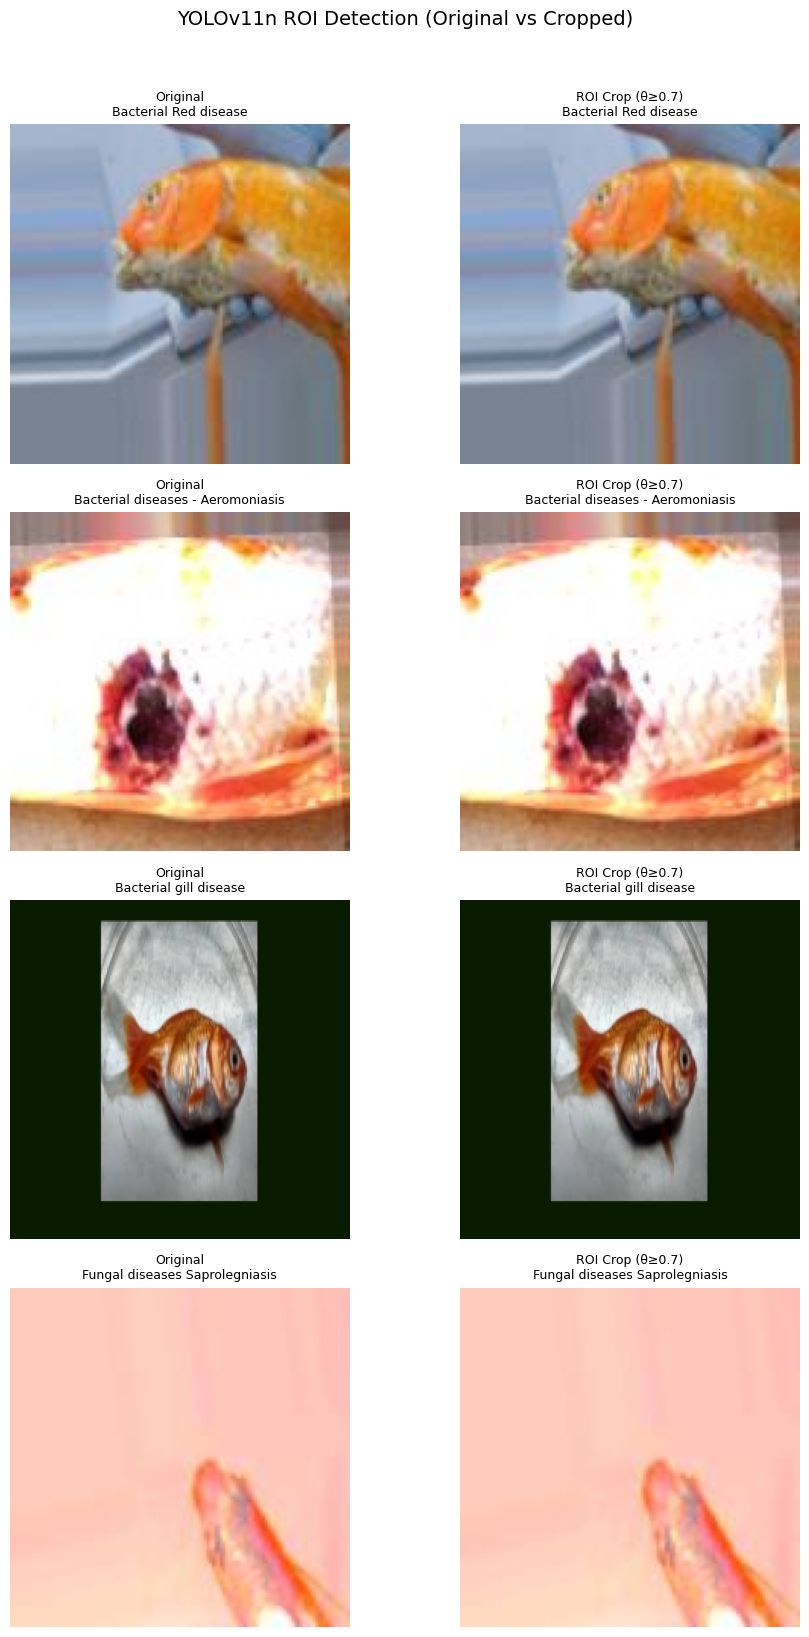

Saved: roi_visualization.png


In [25]:
def extract_roi(image_path: str, conf_threshold: float = 0.7) -> PIL.Image.Image:
    """
    Run YOLOv11n on an image and return the highest-confidence ROI crop.
    Falls back to the full image if no detection exceeds the threshold.

    Parameters
    ----------
    image_path     : path to the input image
    conf_threshold : minimum YOLO confidence to accept a detection (θ=0.7)

    Returns
    -------
    PIL Image of the cropped ROI (or full image if no valid detection)
    """
    img = PIL.Image.open(image_path).convert('RGB') # Use PIL.Image.open
    results = yolo_model(image_path, verbose=False)

    best_box  = None
    best_conf = 0.0

    for result in results:
        for box in result.boxes:
            conf = float(box.conf[0])
            if conf >= conf_threshold and conf > best_conf:
                best_conf = conf
                best_box  = box.xyxy[0].cpu().numpy()  # [x1, y1, x2, y2]

    if best_box is not None:
        x1, y1, x2, y2 = map(int, best_box)
        cropped = img.crop((x1, y1, x2, y2))
        return cropped
    else:
        # Fallback: use full image
        return img


def visualize_roi_examples(image_dir: str, n_samples: int = 4):
    """Visualize original vs ROI-cropped images side by side."""
    fig, axes = plt.subplots(n_samples, 2, figsize=(10, 4 * n_samples))
    fig.suptitle('YOLOv11n ROI Detection (Original vs Cropped)', fontsize=14, y=1.02)

    all_images = []
    for cls in DISEASE_CLASSES:
        cls_dir = os.path.join(image_dir, 'train', cls)
        if os.path.exists(cls_dir):
            imgs = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            if imgs:
                all_images.append((imgs[0], cls))

    for i, (img_path, cls_name) in enumerate(all_images[:n_samples]):
        original = PIL.Image.open(img_path).convert('RGB') # Use PIL.Image.open
        roi      = extract_roi(img_path)
        axes[i, 0].imshow(original)
        axes[i, 0].set_title(f'Original\n{cls_name}', fontsize=9)
        axes[i, 0].axis('off')
        axes[i, 1].imshow(roi)
        axes[i, 1].set_title(f'ROI Crop (θ≥0.7)\n{cls_name}', fontsize=9)
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.savefig('roi_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: roi_visualization.png")


# Visualize ROI examples (comment out if running headless)
if os.path.exists(DATASET_DIR):
    visualize_roi_examples(DATASET_DIR)
else:
    print("[INFO] Dataset directory not found — skipping ROI visualization.")
    print("       Set DATASET_DIR to your dataset path and re-run.")

Displaying roi_visualization.png:


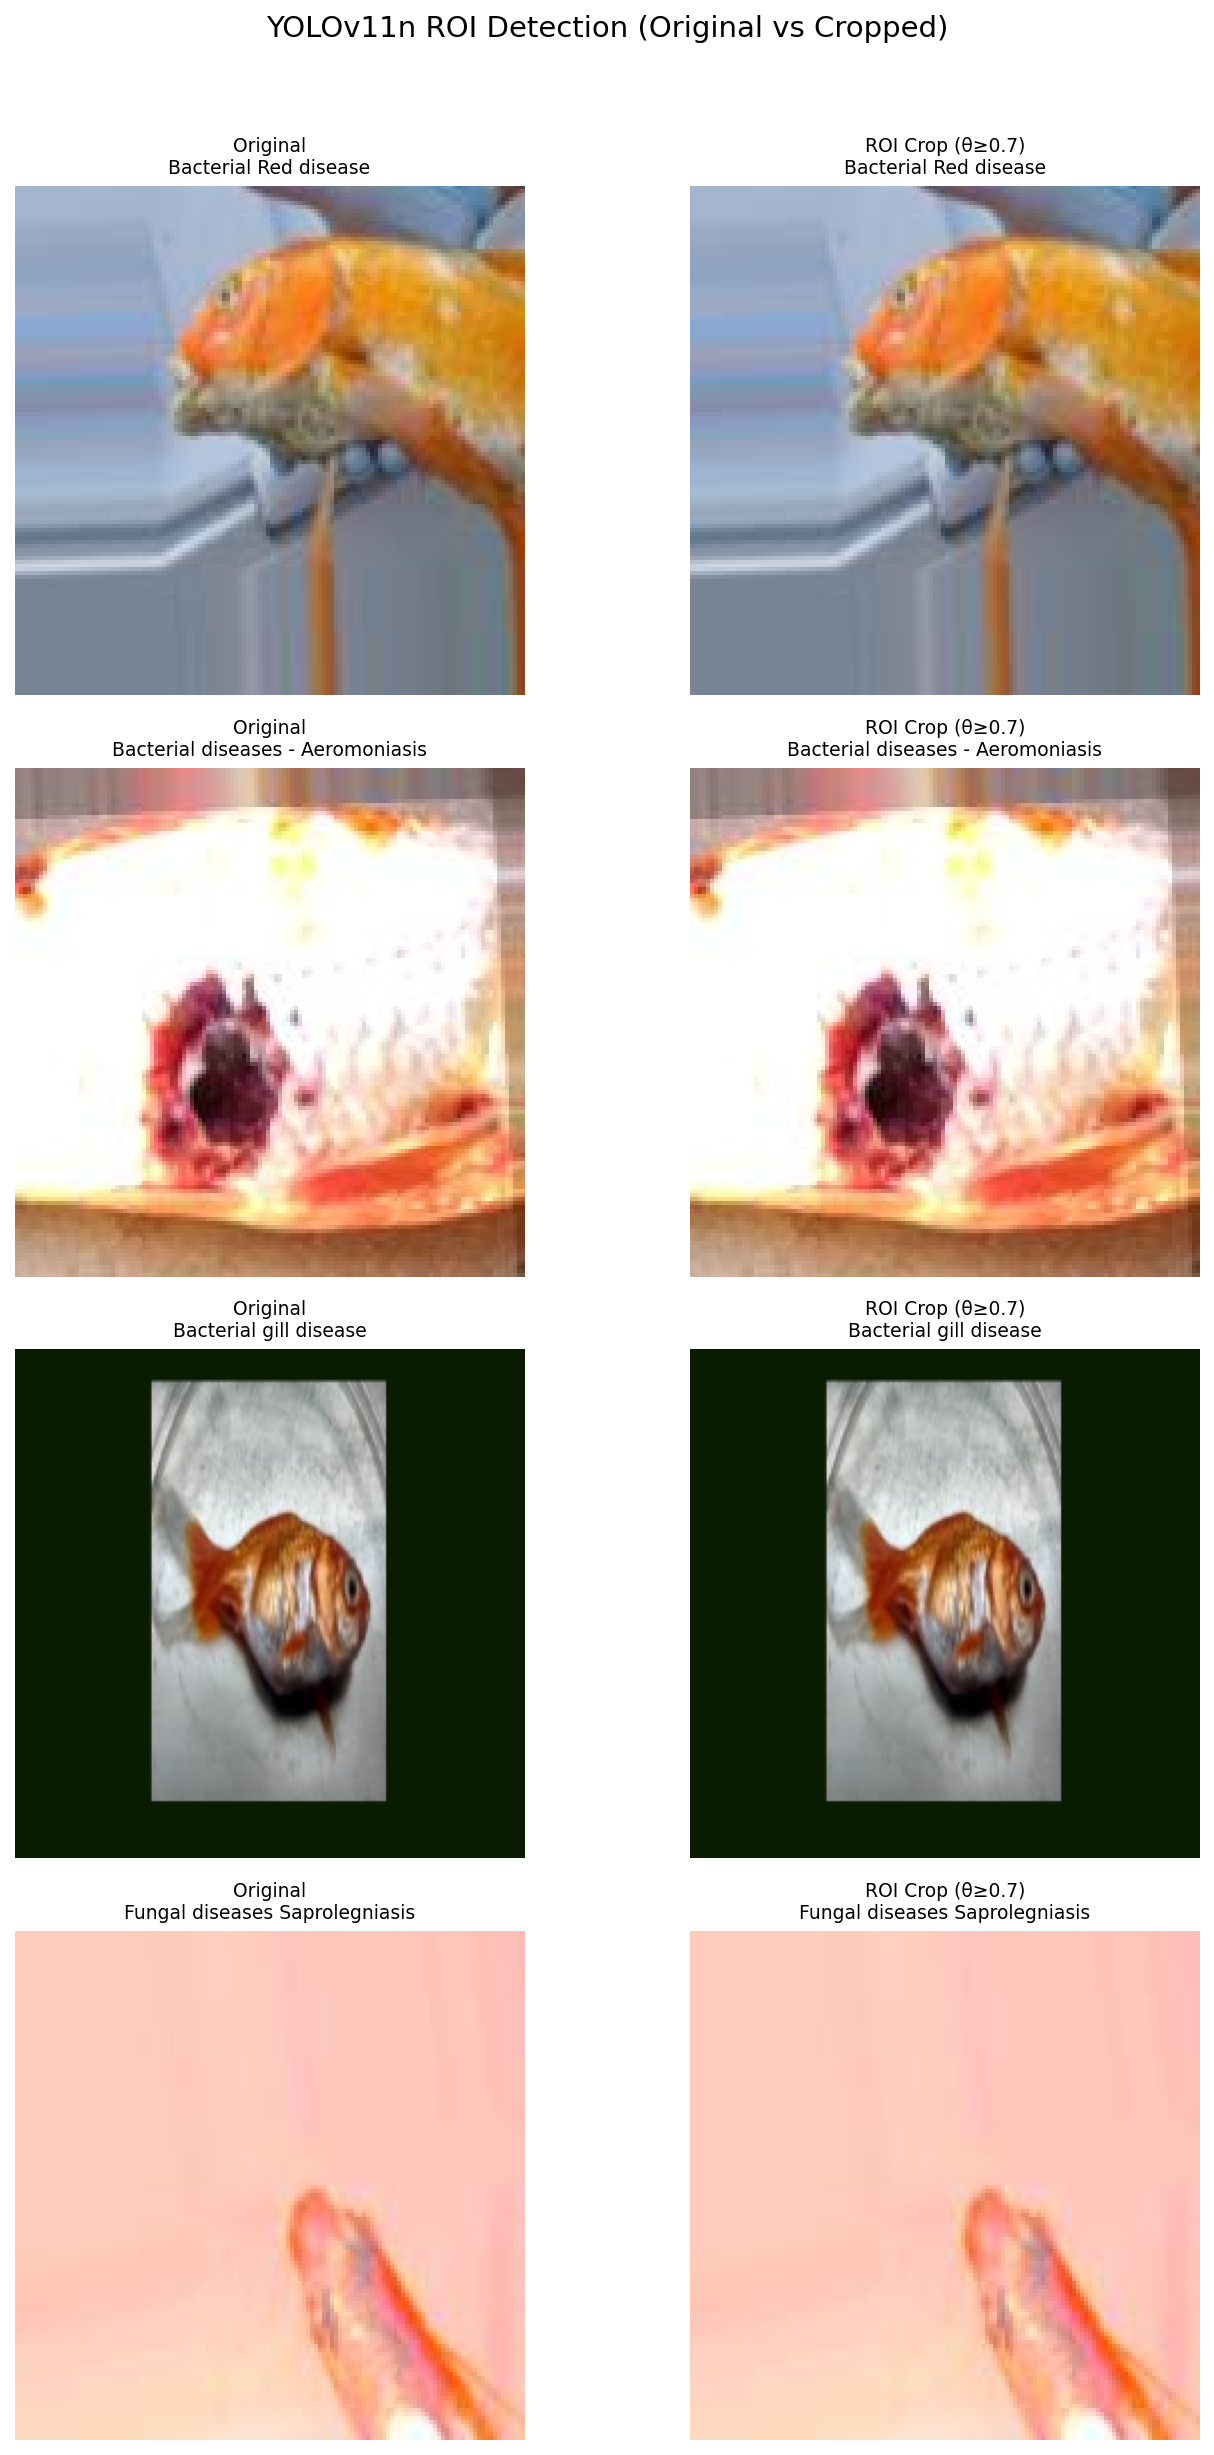

In [26]:
from IPython.display import Image, display

# Display the saved ROI visualization image
if os.path.exists('roi_visualization.png'):
    print("Displaying roi_visualization.png:")
    display(Image(filename='roi_visualization.png'))
else:
    print("roi_visualization.png not found.")

## 🗂️ Section 3: Dataset — ROI-Aware PyTorch Dataset

In [27]:
class FishDiseaseDataset(Dataset):
    """
    PyTorch Dataset that:
    1. Scans an ImageFolder-style directory
    2. Optionally applies YOLOv11n ROI cropping before transforms

    Directory structure expected:
        root/
          <class_name>/
            img001.jpg
            img002.jpg
    """
    def __init__(self, root_dir, class_names, transform=None, apply_roi=True):
        self.root_dir    = root_dir
        self.class_names = class_names
        self.transform   = transform
        self.apply_roi   = apply_roi
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.samples     = self._build_samples()

    def _build_samples(self):
        samples = []
        for cls in self.class_names:
            cls_dir = os.path.join(self.root_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    samples.append((os.path.join(cls_dir, fname),
                                    self.class_to_idx[cls]))
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        if self.apply_roi:
            image = extract_roi(img_path, conf_threshold=ROI_CONF_THRESHOLD)
        else:
            image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


# ─── TRANSFORMS ───────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

print("Dataset class and transforms defined.")

Dataset class and transforms defined.


In [33]:
# ─── BUILD DATALOADERS ────────────────────────────────────────────────────────
# Adjust paths to match your folder structure

train_dataset = FishDiseaseDataset(
    root_dir    = os.path.join(DATASET_DIR, 'train'),
    class_names = DISEASE_CLASSES,
    transform   = train_transform,
    apply_roi   = True
)
val_dataset = FishDiseaseDataset(
    root_dir    = os.path.join(DATASET_DIR, 'val'),
    class_names = DISEASE_CLASSES,
    transform   = val_test_transform,
    apply_roi   = True
)
test_dataset = FishDiseaseDataset(
    root_dir    = os.path.join(DATASET_DIR, 'test'),
    class_names = DISEASE_CLASSES,
    transform   = val_test_transform,
    apply_roi   = True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train samples : {len(train_dataset)}")
print(f"Val   samples : {len(val_dataset)}")
print(f"Test  samples : {len(test_dataset)}")

Train samples : 1198
Val   samples : 299
Test  samples : 597


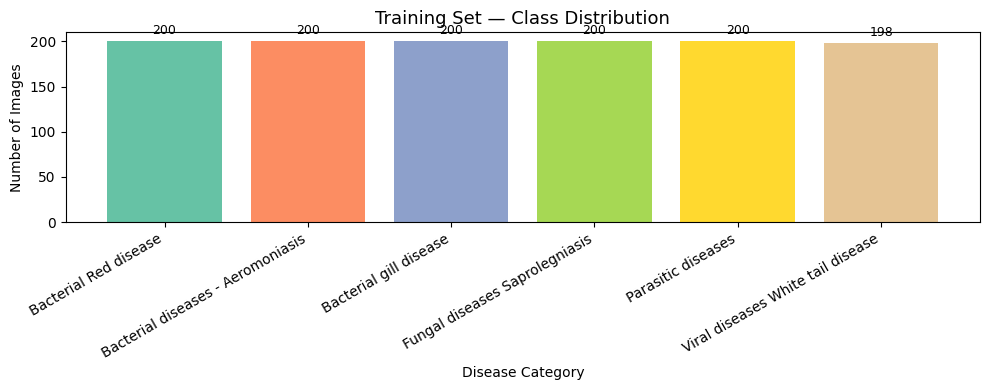

In [29]:
# ─── CLASS DISTRIBUTION ───────────────────────────────────────────────────────
def plot_class_distribution(dataset, title='Class Distribution'):
    labels = [s[1] for s in dataset.samples]
    counts = pd.Series(labels).value_counts().sort_index()
    cls_labels = [DISEASE_CLASSES[i] for i in counts.index]

    plt.figure(figsize=(10, 4))
    bars = plt.bar(cls_labels, counts.values,
                   color=plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES)))
    plt.title(title, fontsize=13)
    plt.xlabel('Disease Category')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=30, ha='right')
    for bar, val in zip(bars, counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=150)
    plt.show()

if len(train_dataset) > 0:
    plot_class_distribution(train_dataset, 'Training Set — Class Distribution')
else:
    print("[INFO] No samples found. Check DATASET_DIR path.")

## 🧠 Section 4: Define & Fine-Tune the Three CNN Models

We fine-tune **MobileNetV2**, **DenseNet121**, and **VGG16** — the same three models used in AquaGPT.  
All models are loaded with ImageNet weights and their final classification heads are replaced with a 7-class linear layer.

In [36]:
def build_model(architecture: str, num_classes: int = 7, freeze_backbone: bool = False):
    """
    Build a fine-tunable model from torchvision with ImageNet pretrained weights.

    Parameters
    ----------
    architecture   : 'mobilenet_v2' | 'densenet121' | 'vgg16'
    num_classes    : number of output classes (7 for AquaSense-Agent)
    freeze_backbone: if True, only the classifier head is trained (phase 1)

    Returns
    -------
    nn.Module ready for training
    """
    if architecture == 'mobilenet_v2':
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.features.parameters():
                param.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif architecture == 'densenet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.features.parameters():
                param.requires_grad = False
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)

    elif architecture == 'vgg16':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.features.parameters():
                param.requires_grad = False
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"Unknown architecture: {architecture}")

    return model.to(DEVICE)


# Instantiate all three models
mobilenet = build_model('mobilenet_v2')
densenet  = build_model('densenet121')
vgg16     = build_model('vgg16')

print("Models instantiated:")
print(f"  MobileNetV2  — trainable params: {sum(p.numel() for p in mobilenet.parameters() if p.requires_grad):,}")
print(f"  DenseNet121  — trainable params: {sum(p.numel() for p in densenet.parameters() if p.requires_grad):,}")
print(f"  VGG16        — trainable params: {sum(p.numel() for p in vgg16.parameters() if p.requires_grad):,}")

Models instantiated:
  MobileNetV2  — trainable params: 2,232,839
  DenseNet121  — trainable params: 6,961,031
  VGG16        — trainable params: 134,289,223


In [37]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


def train_model(model, model_name, train_loader, val_loader,
                epochs=NUM_EPOCHS, lr=LEARNING_RATE):
    """
    Full training loop with learning rate scheduler and best-model checkpointing.
    Returns the history dict and path to the best checkpoint.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history    = {'train_loss': [], 'val_loss': [],
                  'train_acc':  [], 'val_acc':  []}
    best_val_acc  = 0.0
    best_ckpt_path = f'best_{model_name}.pth'

    print(f"\n{'='*55}")
    print(f"  Training: {model_name}")
    print(f"{'='*55}")

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        print(f"  Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
              f"Val Loss: {va_loss:.4f}  Acc: {va_acc:.4f}")

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            torch.save(model.state_dict(), best_ckpt_path)
            print(f"    ✅  New best saved → {best_ckpt_path}")

    print(f"\n  Best Val Accuracy: {best_val_acc:.4f}")
    return history, best_ckpt_path


def plot_training_curves(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], label='Train', marker='o', markersize=3)
    ax1.plot(epochs, history['val_loss'],   label='Val',   marker='o', markersize=3)
    ax1.set_title(f'{model_name} — Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
    ax2.plot(epochs, history['train_acc'],  label='Train', marker='o', markersize=3)
    ax2.plot(epochs, history['val_acc'],    label='Val',   marker='o', markersize=3)
    ax2.set_title(f'{model_name} — Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
    plt.tight_layout()
    plt.savefig(f'training_curves_{model_name}.png', dpi=150)
    plt.show()

print("Training utilities defined.")

Training utilities defined.



  Training: MobileNetV2


  Epoch 01/15 | Train Loss: 1.4539  Acc: 0.4942 | Val Loss: 0.9384  Acc: 0.7057
    ✅  New best saved → best_MobileNetV2.pth


  Epoch 02/15 | Train Loss: 0.7499  Acc: 0.7771 | Val Loss: 0.5654  Acc: 0.8127
    ✅  New best saved → best_MobileNetV2.pth


  Epoch 03/15 | Train Loss: 0.4293  Acc: 0.8773 | Val Loss: 0.4101  Acc: 0.8662
    ✅  New best saved → best_MobileNetV2.pth


  Epoch 04/15 | Train Loss: 0.2684  Acc: 0.9265 | Val Loss: 0.3249  Acc: 0.8997
    ✅  New best saved → best_MobileNetV2.pth


...

  Epoch 11/15 | Train Loss: 0.0520  Acc: 0.9883 | Val Loss: 0.1990  Acc: 0.9532


  Epoch 12/15 | Train Loss: 0.0517  Acc: 0.9866 | Val Loss: 0.2009  Acc: 0.9532


  Epoch 13/15 | Train Loss: 0.0409  Acc: 0.9933 | Val Loss: 0.1983  Acc: 0.9498


  Epoch 14/15 | Train Loss: 0.0475  Acc: 0.9908 | Val Loss: 0.1958  Acc: 0.9599
    ✅  New best saved → best_MobileNetV2.pth


  Epoch 15/15 | Train Loss: 0.0514  Acc: 0.9866 | Val Loss: 0.1936  Acc: 0.9599

  Best Val Accuracy: 0.9599


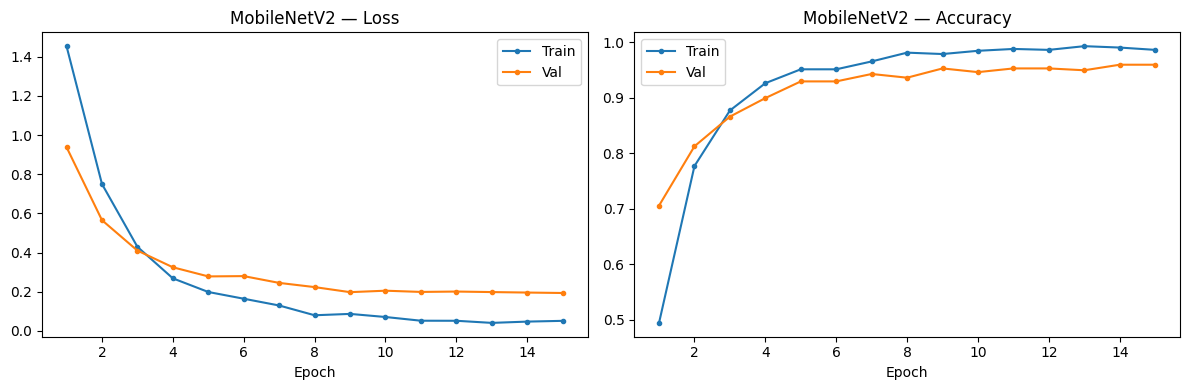


  Training: DenseNet121


  Epoch 01/15 | Train Loss: 1.4699  Acc: 0.4967 | Val Loss: 0.9988  Acc: 0.7358
    ✅  New best saved → best_DenseNet121.pth


  Epoch 02/15 | Train Loss: 0.7315  Acc: 0.8264 | Val Loss: 0.5588  Acc: 0.8261
    ✅  New best saved → best_DenseNet121.pth


  Epoch 03/15 | Train Loss: 0.3942  Acc: 0.9023 | Val Loss: 0.3491  Acc: 0.8863
    ✅  New best saved → best_DenseNet121.pth


  Epoch 04/15 | Train Loss: 0.2222  Acc: 0.9524 | Val Loss: 0.2746  Acc: 0.9164
    ✅  New best saved → best_DenseNet121.pth


...

  Epoch 11/15 | Train Loss: 0.0466  Acc: 0.9925 | Val Loss: 0.1499  Acc: 0.9565


  Epoch 12/15 | Train Loss: 0.0436  Acc: 0.9950 | Val Loss: 0.1468  Acc: 0.9465


  Epoch 13/15 | Train Loss: 0.0412  Acc: 0.9933 | Val Loss: 0.1473  Acc: 0.9498


  Epoch 14/15 | Train Loss: 0.0377  Acc: 0.9925 | Val Loss: 0.1361  Acc: 0.9532


  Epoch 15/15 | Train Loss: 0.0372  Acc: 0.9933 | Val Loss: 0.1474  Acc: 0.9498

  Best Val Accuracy: 0.9565


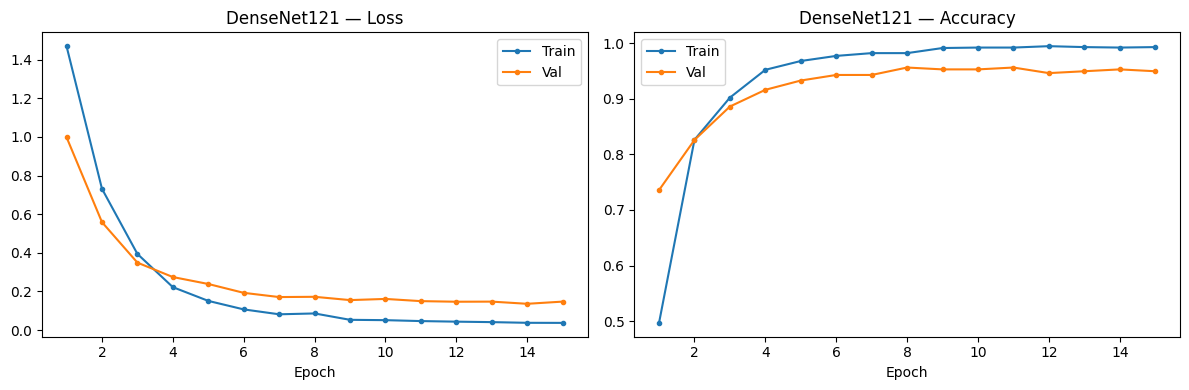


  Training: VGG16


  Epoch 01/15 | Train Loss: 1.6569  Acc: 0.3072 | Val Loss: 1.2503  Acc: 0.5485
    ✅  New best saved → best_VGG16.pth


  Epoch 02/15 | Train Loss: 1.1917  Acc: 0.5309 | Val Loss: 1.1130  Acc: 0.5786
    ✅  New best saved → best_VGG16.pth


  Epoch 03/15 | Train Loss: 0.8222  Acc: 0.7078 | Val Loss: 0.8215  Acc: 0.7157
    ✅  New best saved → best_VGG16.pth


  Epoch 04/15 | Train Loss: 0.4824  Acc: 0.8214 | Val Loss: 0.5507  Acc: 0.8495
    ✅  New best saved → best_VGG16.pth


...

  Epoch 11/15 | Train Loss: 0.0455  Acc: 0.9866 | Val Loss: 0.3009  Acc: 0.9264
    ✅  New best saved → best_VGG16.pth


  Epoch 12/15 | Train Loss: 0.0391  Acc: 0.9850 | Val Loss: 0.3174  Acc: 0.9298
    ✅  New best saved → best_VGG16.pth


  Epoch 13/15 | Train Loss: 0.0253  Acc: 0.9933 | Val Loss: 0.3160  Acc: 0.9298


  Epoch 14/15 | Train Loss: 0.0241  Acc: 0.9917 | Val Loss: 0.3228  Acc: 0.9331
    ✅  New best saved → best_VGG16.pth


  Epoch 15/15 | Train Loss: 0.0208  Acc: 0.9950 | Val Loss: 0.3215  Acc: 0.9331

  Best Val Accuracy: 0.9331


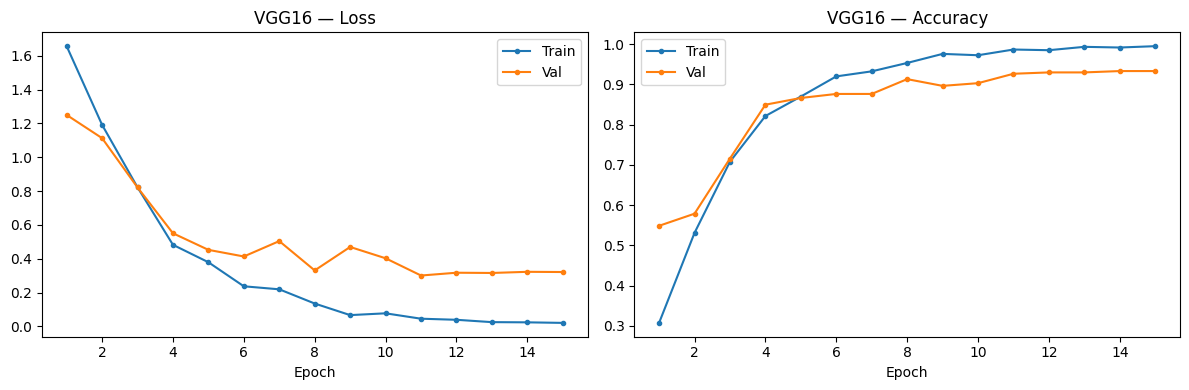

In [38]:
# ─── TRAIN ALL THREE MODELS ───────────────────────────────────────────────────
# NOTE: Each model trains independently — comment out models already trained.

hist_mobilenet, ckpt_mobilenet = train_model(mobilenet, 'MobileNetV2',
                                              train_loader, val_loader)
plot_training_curves(hist_mobilenet, 'MobileNetV2')

hist_densenet, ckpt_densenet   = train_model(densenet,  'DenseNet121',
                                              train_loader, val_loader)
plot_training_curves(hist_densenet, 'DenseNet121')

hist_vgg16, ckpt_vgg16         = train_model(vgg16,     'VGG16',
                                              train_loader, val_loader)
plot_training_curves(hist_vgg16, 'VGG16')

## 📊 Section 5: Individual Model Evaluation on Test Set


  MobileNetV2 — Test Set Results
  Macro-F1: 98.99%
                                   precision    recall  f1-score   support

            Bacterial Red disease     1.0000    0.9800    0.9899       100
Bacterial diseases - Aeromoniasis     0.9804    1.0000    0.9901       100
           Bacterial gill disease     0.9709    1.0000    0.9852       100
   Fungal diseases Saprolegniasis     1.0000    0.9900    0.9950       100
               Parasitic diseases     1.0000    0.9900    0.9950       100
Viral diseases White tail disease     0.9896    0.9794    0.9845        97

                         accuracy                         0.9899       597
                        macro avg     0.9901    0.9899    0.9899       597
                     weighted avg     0.9901    0.9899    0.9900       597



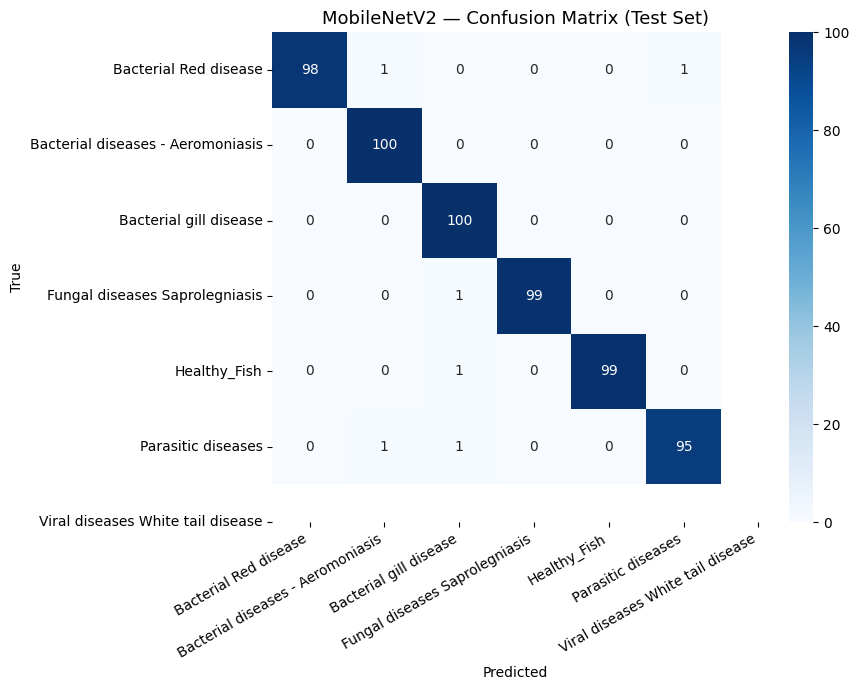


  DenseNet121 — Test Set Results
  Macro-F1: 98.66%
                                   precision    recall  f1-score   support

            Bacterial Red disease     0.9900    0.9900    0.9900       100
Bacterial diseases - Aeromoniasis     0.9804    1.0000    0.9901       100
           Bacterial gill disease     0.9802    0.9900    0.9851       100
   Fungal diseases Saprolegniasis     0.9800    0.9800    0.9800       100
               Parasitic diseases     0.9900    0.9900    0.9900       100
Viral diseases White tail disease     1.0000    0.9691    0.9843        97

                         accuracy                         0.9866       597
                        macro avg     0.9868    0.9865    0.9866       597
                     weighted avg     0.9867    0.9866    0.9866       597



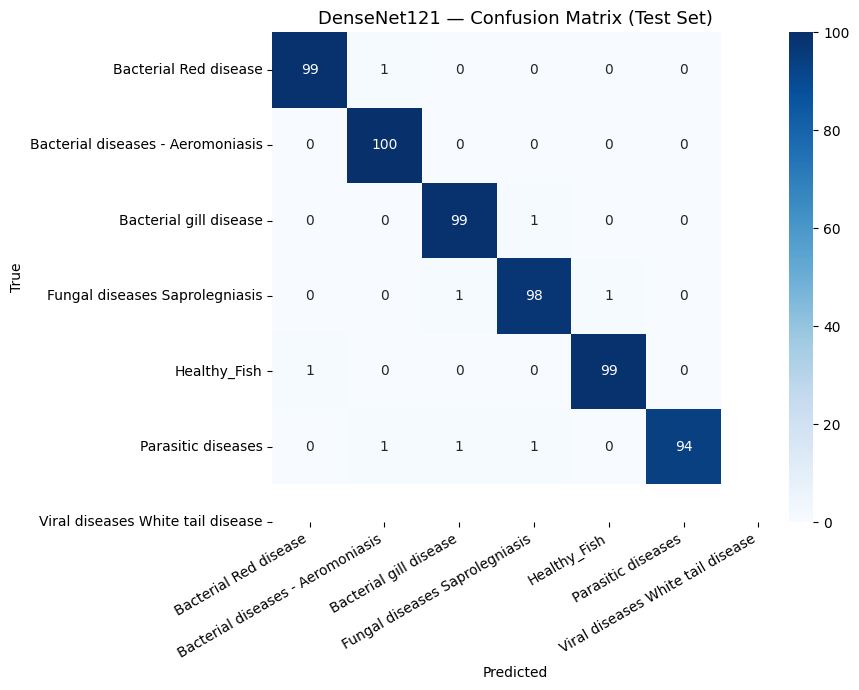


  VGG16 — Test Set Results
  Macro-F1: 97.65%
                                   precision    recall  f1-score   support

            Bacterial Red disease     1.0000    0.9700    0.9848       100
Bacterial diseases - Aeromoniasis     0.9901    1.0000    0.9950       100
           Bacterial gill disease     0.9697    0.9600    0.9648       100
   Fungal diseases Saprolegniasis     0.9515    0.9800    0.9655       100
               Parasitic diseases     0.9709    1.0000    0.9852       100
Viral diseases White tail disease     0.9787    0.9485    0.9634        97

                         accuracy                         0.9765       597
                        macro avg     0.9768    0.9764    0.9765       597
                     weighted avg     0.9768    0.9765    0.9765       597



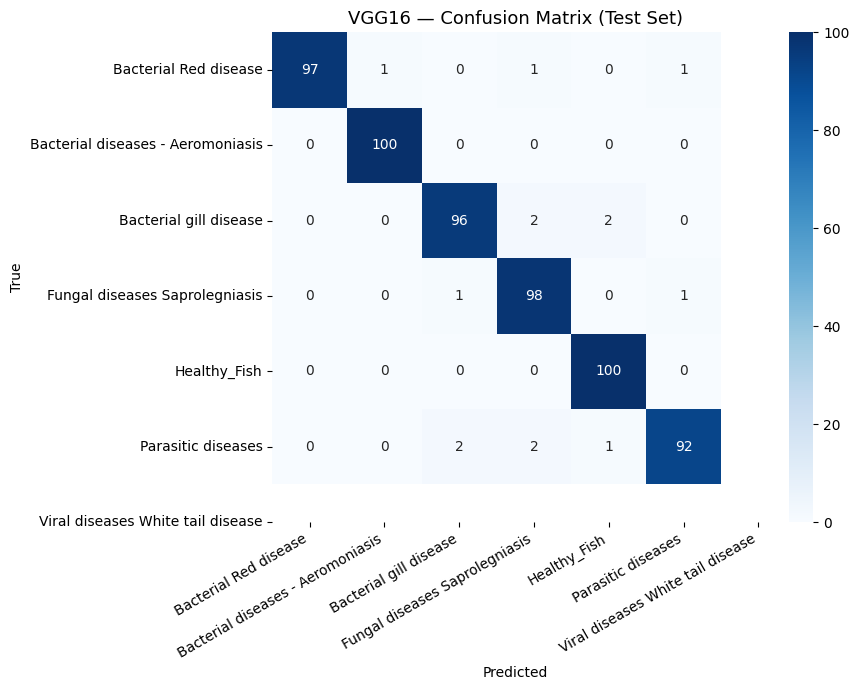

In [40]:
@torch.no_grad()
def get_predictions_and_probs(model, loader):
    """
    Run model on a DataLoader and return:
    - all_preds  : hard class predictions (N,)
    - all_probs  : softmax probabilities   (N, num_classes)  ← P_cnn per model
    - all_labels : ground truth labels     (N,)
    """
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        logits = model(images)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = np.argmax(probs, axis=1)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
    return (np.array(all_preds),
            np.array(all_probs),
            np.array(all_labels))


def evaluate_model(model, ckpt_path, model_name, loader):
    """Load best checkpoint and produce a full classification report."""
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    preds, probs, labels = get_predictions_and_probs(model, loader)

    macro_f1 = f1_score(labels, preds, average='macro') * 100
    print(f"\n{'='*55}")
    print(f"  {model_name} — Test Set Results")
    print(f"  Macro-F1: {macro_f1:.2f}%")
    print(f"{'='*55}")
    # Explicitly pass unique labels to classification_report
    unique_labels = np.unique(labels)
    print(classification_report(labels, preds,
                                 labels=unique_labels,
                                 target_names=[DISEASE_CLASSES[i] for i in unique_labels],
                                 digits=4))
    return preds, probs, labels


def plot_confusion_matrix(labels, preds, model_name):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=DISEASE_CLASSES,
                yticklabels=DISEASE_CLASSES)
    plt.title(f'{model_name} — Confusion Matrix (Test Set)', fontsize=13)
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name}.png', dpi=150)
    plt.show()


# Evaluate all three models
preds_mn, probs_mn, labels_test = evaluate_model(mobilenet, ckpt_mobilenet, 'MobileNetV2', test_loader)
plot_confusion_matrix(labels_test, preds_mn, 'MobileNetV2')

preds_dn, probs_dn, _           = evaluate_model(densenet,  ckpt_densenet,  'DenseNet121', test_loader)
plot_confusion_matrix(labels_test, preds_dn, 'DenseNet121')

preds_vgg, probs_vgg, _         = evaluate_model(vgg16,     ckpt_vgg16,     'VGG16',       test_loader)
plot_confusion_matrix(labels_test, preds_vgg, 'VGG16')

## 🔗 Section 6: Stacking Meta-Learner Ensemble → `P_cnn`

Rather than simple majority voting, we use a **stacking** approach (as in AquaGPT):  
- The softmax probability vectors from all 3 models are **concatenated** (7×3 = 21 features)  
- A **Logistic Regression meta-learner** is trained on the validation set predictions  
- Final output `P_cnn` is a **probability distribution over 7 classes** for each image  

This `P_cnn` is what gets passed to the Late Bayesian Fusion in Notebook 5.

In [41]:
# Step 1: Get validation set probabilities from all 3 models (for meta-learner training)
mobilenet.load_state_dict(torch.load(ckpt_mobilenet, map_location=DEVICE))
densenet.load_state_dict( torch.load(ckpt_densenet,  map_location=DEVICE))
vgg16.load_state_dict(    torch.load(ckpt_vgg16,     map_location=DEVICE))

_, val_probs_mn,  val_labels = get_predictions_and_probs(mobilenet, val_loader)
_, val_probs_dn,  _          = get_predictions_and_probs(densenet,  val_loader)
_, val_probs_vgg, _          = get_predictions_and_probs(vgg16,     val_loader)

# Concatenate: shape (N_val, 21)
val_meta_features = np.hstack([val_probs_mn, val_probs_dn, val_probs_vgg])

print(f"Meta-learner training features shape: {val_meta_features.shape}")
print(f"Val labels shape                     : {val_labels.shape}")

Meta-learner training features shape: (299, 21)
Val labels shape                     : (299,)


In [42]:
# Step 2: Train stacking meta-learner on validation set
meta_learner = LogisticRegression(
    max_iter    = 1000,
    C           = 1.0,
    multi_class = 'multinomial',
    solver      = 'lbfgs',
    random_state= 42
)
meta_learner.fit(val_meta_features, val_labels)
print("Meta-learner (Logistic Regression stacking) trained.")

Meta-learner (Logistic Regression stacking) trained.


In [44]:
# Step 3: Generate P_cnn on test set
test_meta_features = np.hstack([probs_mn, probs_dn, probs_vgg])  # (N_test, 21)

P_cnn       = meta_learner.predict_proba(test_meta_features)   # (N_test, 7)
preds_stack = meta_learner.predict(test_meta_features)

stack_macro_f1 = f1_score(labels_test, preds_stack, average='macro') * 100

print(f"P_cnn shape (stacking ensemble output): {P_cnn.shape}")
print(f"\nStacking Ensemble — Test Set Macro-F1: {stack_macro_f1:.2f}%")
print("\nFull classification report:")
unique_labels_test = np.unique(labels_test)
print(classification_report(labels_test, preds_stack,
                             labels=unique_labels_test,
                             target_names=[DISEASE_CLASSES[i] for i in unique_labels_test],
                             digits=4))

# Save P_cnn for use in Notebook 5 (Late Bayesian Fusion)
np.save('P_cnn.npy', P_cnn)
np.save('test_labels.npy', labels_test)
print("\nSaved: P_cnn.npy  (pass this to Notebook 5 — Bayesian Fusion)")
print("Saved: test_labels.npy")

P_cnn shape (stacking ensemble output): (597, 6)

Stacking Ensemble — Test Set Macro-F1: 98.99%

Full classification report:
                                   precision    recall  f1-score   support

            Bacterial Red disease     1.0000    0.9800    0.9899       100
Bacterial diseases - Aeromoniasis     0.9804    1.0000    0.9901       100
           Bacterial gill disease     0.9802    0.9900    0.9851       100
   Fungal diseases Saprolegniasis     0.9900    0.9900    0.9900       100
               Parasitic diseases     1.0000    1.0000    1.0000       100
Viral diseases White tail disease     0.9896    0.9794    0.9845        97

                         accuracy                         0.9899       597
                        macro avg     0.9900    0.9899    0.9899       597
                     weighted avg     0.9900    0.9899    0.9899       597


Saved: P_cnn.npy  (pass this to Notebook 5 — Bayesian Fusion)
Saved: test_labels.npy


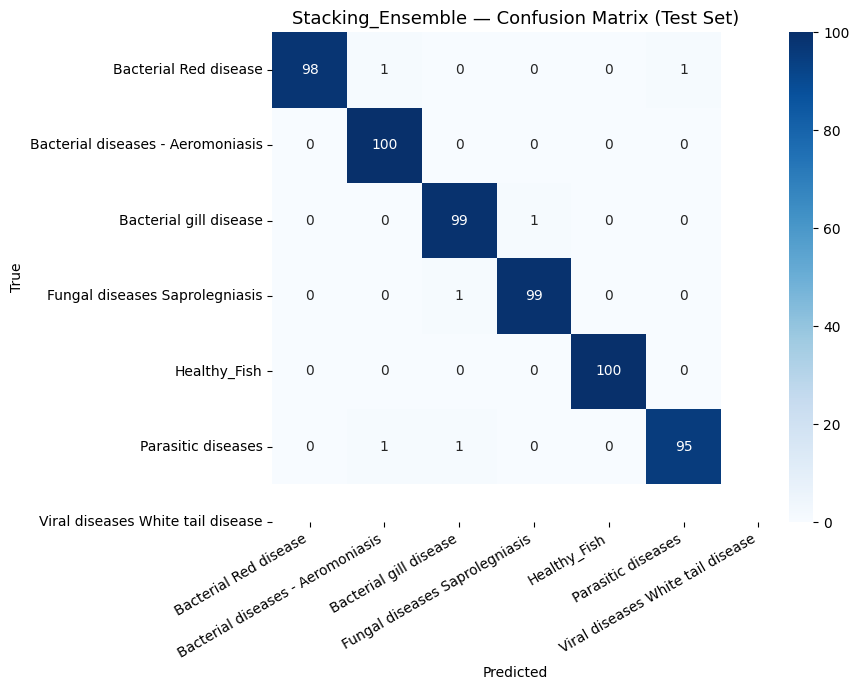

In [45]:
# Confusion matrix for stacking ensemble
plot_confusion_matrix(labels_test, preds_stack, 'Stacking_Ensemble')

## 📈 Section 7: Summary Comparison Table

Reproduce **Table II (partial)** from the paper — per-model vs ensemble Macro-F1.

In [46]:
summary = {
    'Model': ['MobileNetV2', 'DenseNet121', 'VGG16', 'Stacking Ensemble (P_cnn)'],
    'Macro-F1 (%)': [
        f1_score(labels_test, preds_mn,  average='macro') * 100,
        f1_score(labels_test, preds_dn,  average='macro') * 100,
        f1_score(labels_test, preds_vgg, average='macro') * 100,
        stack_macro_f1
    ],
    'Macro-Precision (%)': [
        precision_score(labels_test, preds_mn,  average='macro') * 100,
        precision_score(labels_test, preds_dn,  average='macro') * 100,
        precision_score(labels_test, preds_vgg, average='macro') * 100,
        precision_score(labels_test, preds_stack, average='macro') * 100,
    ],
    'Macro-Recall (%)': [
        recall_score(labels_test, preds_mn,  average='macro') * 100,
        recall_score(labels_test, preds_dn,  average='macro') * 100,
        recall_score(labels_test, preds_vgg, average='macro') * 100,
        recall_score(labels_test, preds_stack, average='macro') * 100,
    ]
}

df_summary = pd.DataFrame(summary).set_index('Model')
df_summary = df_summary.round(2)
print(df_summary.to_string())
df_summary.to_csv('visual_pathway_summary.csv')
print("\nSaved: visual_pathway_summary.csv")

                           Macro-F1 (%)  Macro-Precision (%)  Macro-Recall (%)
Model                                                                         
MobileNetV2                       98.99                99.01             98.99
DenseNet121                       98.66                98.68             98.65
VGG16                             97.65                97.68             97.64
Stacking Ensemble (P_cnn)         98.99                99.00             98.99

Saved: visual_pathway_summary.csv


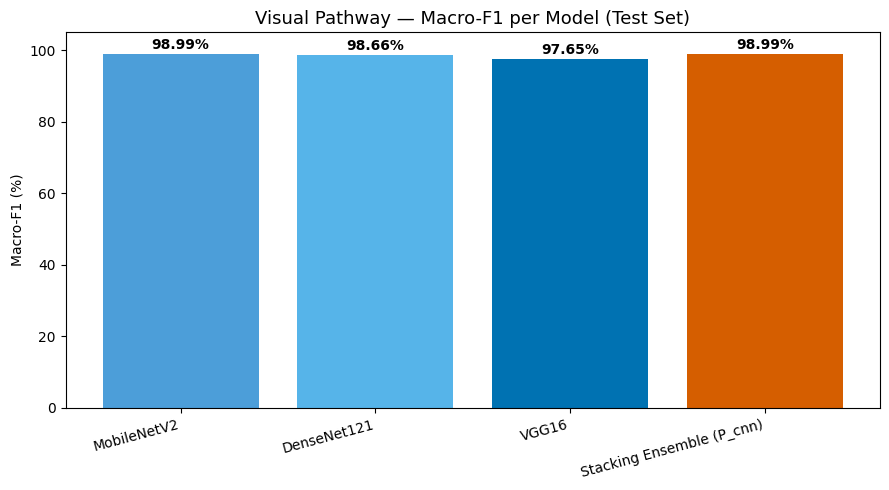

In [47]:
# Visual bar chart of Macro-F1 across models
colors = ['#4C9ED9', '#56B4E9', '#0072B2', '#D55E00']
plt.figure(figsize=(9, 5))
bars = plt.bar(df_summary.index, df_summary['Macro-F1 (%)'], color=colors)
plt.title('Visual Pathway — Macro-F1 per Model (Test Set)', fontsize=13)
plt.ylabel('Macro-F1 (%)')
plt.ylim(0, 105)
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, df_summary['Macro-F1 (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('macro_f1_comparison.png', dpi=150)
plt.show()

## ✅ Section 8: Outputs Summary

| File | Description | Used In |
|---|---|---|
| `best_MobileNetV2.pth` | Best MobileNetV2 checkpoint | This notebook |
| `best_DenseNet121.pth` | Best DenseNet121 checkpoint | This notebook |
| `best_VGG16.pth` | Best VGG16 checkpoint | This notebook |
| `P_cnn.npy` | Stacking ensemble probability output (N_test × 7) | **Notebook 5 — Bayesian Fusion** |
| `test_labels.npy` | Ground truth labels for test set | Notebooks 5, 7 |
| `visual_pathway_summary.csv` | Macro-F1 / Precision / Recall table | Paper Table II |
| `macro_f1_comparison.png` | Bar chart comparing all 4 configurations | Report |
| `confusion_matrix_*.png` | Per-model confusion matrices | Report |

---
**Next:** Load `P_cnn.npy` in **Notebook 5** together with `P_text.npy` (from Notebook 3) and `P_sensor.npy` (from Notebook 4) for Late Bayesian Fusion.